In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [5]:
import pandas as pd

data = pd.read_csv(r"C:\Users\ADMIN\Downloads\credit_scoring_dataset.csv")

print(data.head())

  Customer_ID  Age  Gender  Monthly_Income Employment_Status  Existing_Debt  \
0        C101   25    Male           50000          Salaried         120000   
1        C102   32  Female           35000     Self-employed         180000   
2        C103   28    Male           75000          Salaried         100000   
3        C104   45  Female           42000          Business         250000   
4        C105   30    Male           68000          Salaried          90000   

     EMI  Credit_Limit  Bill_Amount  Payment_Amount  Late_Payments  \
0   5000        200000        45000           40000              0   
1   9000        150000        95000           20000              3   
2   4500        300000        30000           28000              1   
3  12000        180000       110000           15000              4   
4   3500        250000        25000           24000              0   

   Transaction_Count  Avg_Transaction  Savings_Balance  Credit_Utilization  \
0                 35      

In [6]:
#checkk dataset information 
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10 non-null     object 
 1   Age                 10 non-null     int64  
 2   Gender              10 non-null     object 
 3   Monthly_Income      10 non-null     int64  
 4   Employment_Status   10 non-null     object 
 5   Existing_Debt       10 non-null     int64  
 6   EMI                 10 non-null     int64  
 7   Credit_Limit        10 non-null     int64  
 8   Bill_Amount         10 non-null     int64  
 9   Payment_Amount      10 non-null     int64  
 10  Late_Payments       10 non-null     int64  
 11  Transaction_Count   10 non-null     int64  
 12  Avg_Transaction     10 non-null     int64  
 13  Savings_Balance     10 non-null     int64  
 14  Credit_Utilization  10 non-null     float64
 15  Debt_to_Income      10 non-null     float64
 16  Payment_His

In [7]:
#Encode categorical data :
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data['Employment_Status'] = le.fit_transform(data['Employment_Status'])
data['Payment_History'] = le.fit_transform(data['Payment_History'])

In [8]:
#remove customer id 
data = data.drop('Customer_ID', axis=1)

In [9]:
#separae feature and target 
X = data.drop('Default', axis=1)

y = data['Default']

In [19]:
#split dataset 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
#train_logistic_regression 
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [21]:
#train_decision_tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [22]:
#train_random_forest
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
rf = RandomForestClassifier()

# Train model
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Accuracy: 1.0


In [25]:
#calculating accuracy , precision , recall , f1-score , ROC-AUC

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

y_prob = rf.predict_proba(X_test)[:,1]

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

Random Forest Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [26]:
#comparing all models 
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 0.5
Random Forest Accuracy: 1.0


In [27]:
#comparing all models 
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 0.5
Random Forest Accuracy: 1.0


In [29]:
# Compare model accuracies

lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

# Finding Best Model

best_accuracy = max(lr_acc, dt_acc, rf_acc)

if best_accuracy == lr_acc:
    print("Best Model: Logistic Regression")

elif best_accuracy == dt_acc:
    print("Best Model: Decision Tree")

else:
    print("Best Model: Random Forest")

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 0.5
Random Forest Accuracy: 1.0
Best Model: Logistic Regression


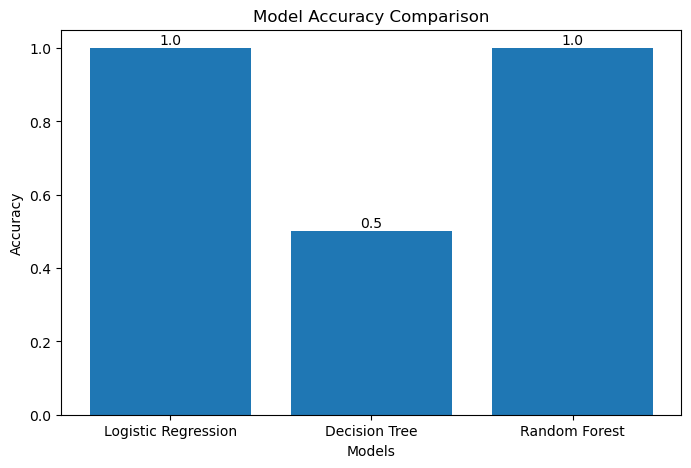

In [31]:
#accuracy comparision bar graph
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

# Accuracy values
accuracies = [lr_acc, dt_acc, rf_acc]

# Create bar graph
plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Show accuracy values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v,2)), ha='center')

# Show graph
plt.show()